In [1]:
import os
import re
import sys
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import pickle
from tqdm import tqdm
from collections import defaultdict
from scipy.stats import zscore

import utils

sub = 'sub-01'
subs = ['sub-01', 'sub-02', 'sub-04']

utils.seed_everything(315)

In [3]:
dic = {}

test_images = [f'A_{i}' for i in range(1,19)] + [f'B_{i}' for i in range(1,19)]

data_folder = '/scratch/gpfs/KNORMAN/wanjia/mindeye_testing/real_time_mindEye2/bixby_data/'

sessions = ['study', 'test', 'snap']

folder_path = os.path.join(data_folder, 'afni')

for sub in subs:

    with open(f'{folder_path}/{sub}_roi_vox_all_sessions.pkl', 'rb') as file:
        dic[sub] = pickle.load(file)

    union_mask = dic[sub]['union_mask']
    print('NSD mask size:', union_mask.shape)
    print('union mask size:', sum(union_mask))
    for ses in sessions:
        dic[sub][ses]['roi'] = dic[sub][ses]['roi'][:, union_mask]
        # z-score each session
        dic[sub][ses]['roi'] = np.nan_to_num(zscore(dic[sub][ses]['roi'], axis=0))
        s = dic[sub][ses]['roi'].shape
        print(f'{ses}: {s}')

NSD mask size: (16946,)
union mask size: 5796
study: (216, 5796)
test: (216, 5796)
snap: (432, 5796)
NSD mask size: (17175,)
union mask size: 3643
study: (216, 3643)
test: (216, 3643)
snap: (432, 3643)
NSD mask size: (20397,)
union mask size: 5887
study: (216, 5887)
test: (216, 5887)
snap: (432, 5887)


In [4]:
for key in dic:
    for ses in sessions:
        print(key, ses)
        print(dic[key][ses]['trial'][0])
        print(dic[key][ses]['roi'].shape)

sub-01 study
scene_A_10_study
(216, 5796)
sub-01 test
scene_A_10_test
(216, 5796)
sub-01 snap
scene_A_10_1
(432, 5796)
sub-02 study
scene_A_10_study
(216, 3643)
sub-02 test
scene_A_10_test
(216, 3643)
sub-02 snap
scene_A_10_1
(432, 3643)
sub-04 study
scene_A_10_study
(216, 5887)
sub-04 test
scene_A_10_test
(216, 5887)
sub-04 snap
scene_A_10_1
(432, 5887)


In [5]:
def find_repeated_strings(string_list):
    """
    Finds all repeated strings in a list and returns a dictionary 
    with the string as the key and a list of its indices as the value.
    Uses a set to track seen items efficiently.
    """
    # Set to quickly track which items have appeared once already
    seen_once = set()
    # Dictionary to store only the indices of items that repeat
    repeated_strings_dict = {}

    for index, string_val in enumerate(string_list):
        if string_val in repeated_strings_dict:
            # If already in the 'repeated_strings_dict', just append the new index
            repeated_strings_dict[string_val].append(index)
        elif string_val in seen_once:
            # First time seeing a repeat: move from 'seen_once' to 'repeated_strings_dict'
            repeated_strings_dict[string_val] = [string_list.index(string_val), index]
        else:
            # First time seeing the item overall
            seen_once.add(string_val)
            
    return repeated_strings_dict

def locate_repeat_index_per_run(sub_dict):
    
    vox = sub_dict['roi']
    runs = sub_dict['run']
    unique_runs = list(set(runs))
    trials = ["_".join(trial.split('_')[1:-1]) for trial in sub_dict['trial']]
    repeated_trial = find_repeated_strings(trials)

    # structure output idx dictionary
    unique_runs.sort()
    default_value = {}
    sorted_vox = dict.fromkeys(unique_runs, default_value)
    for k in sorted_vox.keys():
        sorted_vox[k] = defaultdict(list)
        
    for trial in test_images:
        idx_list = repeated_trial[trial]
        for i in idx_list:
            curr_run = runs[i]
            sorted_vox[curr_run][trial].append(i)
    
    return repeated_trial, sorted_vox

In [6]:
def average_repeats_across_run(vox, repeated_trial, unique_images):
        
    sorted_vox = np.zeros((len(unique_images), vox.shape[1]))
    assert len(repeated_trial.keys()) == len(unique_images)
    
    # Average repeated MST images
    for i, img in enumerate(unique_images):

        if img in repeated_trial.keys(): # deal with repeated images
            # average all repeats across sessions
            curr_trial_vox = np.mean(vox[repeated_trial[img]], axis=0)
            
        else: # error handeling
            print(f"{img} is not in the list")
            break
        
        sorted_vox[i, :] = curr_trial_vox
    
    return sorted_vox


def average_repeats_for_each_run(vox, per_run_repeat_idx, unique_images):
    
    sorted_dict = {}
        
    for run in per_run_repeat_idx.keys():
        
        sorted_dict[run] = np.zeros((len(unique_images), vox.shape[1]))
        idx_dict = per_run_repeat_idx[run]
    
        # Average repeated MST images
        for i, img in enumerate(unique_images):

            if img in idx_dict.keys(): # deal with repeated images
                # average all repeats across sessions
                curr_trial_vox = np.mean(vox[idx_dict[img]], axis=0)

            else: # error handeling
                print(f"{img} is not in the list")
                break

            sorted_dict[run][i, :] = curr_trial_vox
            
        assert len(per_run_repeat_idx[run].keys()) == len(unique_images)

    
    return sorted_dict

In [7]:
# Loading Snap data
tasks = ['study', 'test', 'snap']
vox_by_run = {}

for sub in subs:
    
    vox_by_run[sub] = {}
    
    for task in tasks:

        sub_dict = dic[sub][task]

        repeat_idx, per_run_repeat_idx = locate_repeat_index_per_run(sub_dict)

        vox_by_run[sub][task] = average_repeats_for_each_run(sub_dict['roi'], per_run_repeat_idx, test_images) # averaging all repeats across run in the sequence of test_images

        

In [29]:
## Combine study/test/snap

avg_dic = {}

for sub in subs:
    
    avg_dic[sub] = {}
    
    avg_dic[sub]['odd'] = []
    avg_dic[sub]['even'] = []
    
    for task in tasks:
        
        curr_dict = vox_by_run[sub][task]
        
        avg_dic[sub]['odd'].extend([curr_dict[k] for k in ['run-01','run-03','run-05']])
        avg_dic[sub]['even'].extend([curr_dict[k] for k in ['run-02','run-04','run-06']])
    
    avg_dic[sub]['odd'] = np.mean(np.stack(avg_dic[sub]['odd']), axis=0)
    avg_dic[sub]['even'] = np.mean(np.stack(avg_dic[sub]['even']), axis = 0)
    
    
    # Stack A and B vertically to get a [72, 1000] matrix
    combined = np.vstack([avg_dic[sub]['odd'], avg_dic[sub]['even']])
    # np.corrcoef returns a [72, 72] matrix
    full_matrix = np.corrcoef(combined)
    # Extract the top-right [36, 36] block (Correlations of A rows with B rows)
    avg_dic[sub]['correlation'] = full_matrix[:36, 36:]
    
#     corr_matrix = np.empty((len(avg_dic[sub]['odd']), len(avg_dic[sub]['even'])))
#     for i in range(len(avg_dic[sub]['odd'])):
#         for j in range(len(avg_dic[sub]['even'])):
#             corr_matrix[i,j]=np.corrcoef(avg_dic[sub]['odd'][i], avg_dic[sub]['even'][j])[0,1]

In [31]:

overall = {}
sd = {}

for sub in subs:
    same = []
    competitor = []
    others = []
    overall[sub] = {}
    sd[sub] = {}
    
    overall_score = 0.
    with_pair_score = 0.
    across_pair_score = 0.
    count = 0.
    
    for i, img in enumerate(test_images):
        img_folder = img.split('_')[0]
        img_id = img.split('_')[-1]

        same_idx = i
        competitor_folder= 'A' if img_folder == 'B' else 'B'
        competitor_idx = test_images.index(competitor_folder+'_'+img_id)

        #print('img:', img_folder, img_id, '@ idx', same_idx)
        #print('competitor:', competitor_folder, img_id, '@ idx', competitor_idx)

        curr_arr = avg_dic[sub]['correlation'][i]
        same.append(curr_arr[i])
        competitor.append(curr_arr[competitor_idx])

        indices_to_exclude = np.array([i, competitor_idx])
        # Create a boolean mask indicating elements NOT in the exclusion list
        mask = ~np.isin(np.arange(len(curr_arr)), indices_to_exclude)

        # Use the mask to select the elements
        others.append(curr_arr[mask])
        
        if curr_arr[i] > curr_arr[competitor_idx]:
            with_pair_score += 1
        if curr_arr[i] > max(curr_arr[mask]):
            across_pair_score += 1
        if curr_arr[i] > max(curr_arr[mask]) and curr_arr[i] > curr_arr[competitor_idx]:
            overall_score += 1
        
        count += 1
        
        
    # Look at columns for each evaluation
    for i, img in enumerate(test_images):
        
        img_folder = img.split('_')[0]
        img_id = img.split('_')[-1]

        same_idx = i
        competitor_folder= 'A' if img_folder == 'B' else 'B'
        competitor_idx = test_images.index(competitor_folder+'_'+img_id)

        curr_arr = avg_dic[sub]['correlation'][:,i]

        indices_to_exclude = np.array([i, competitor_idx])
        # Create a boolean mask indicating elements NOT in the exclusion list
        mask = ~np.isin(np.arange(len(curr_arr)), indices_to_exclude)

        if curr_arr[i] > curr_arr[competitor_idx]:
            with_pair_score += 1
        if curr_arr[i] > max(curr_arr[mask]):
            across_pair_score += 1
        if curr_arr[i] > max(curr_arr[mask]) and curr_arr[i] > curr_arr[competitor_idx]:
            overall_score += 1
        
        count += 1
        
    print(sub)
    
    print(count)
    
    print('within item vs. all: ', overall_score/count)
    print('within item vs. within pair: ', with_pair_score/count)
    print('within item vs. across pair: ', across_pair_score/count)

    
    overall[sub]['within_item'] = np.mean(same)
    overall[sub]['within_pair'] = np.mean(competitor)
    overall[sub]['across_pair'] = np.mean(others)
    
    sd [sub]['within_item'] = np.std(same) / np.sqrt(len(same))
    sd [sub]['within_pair'] = np.std(competitor) / np.sqrt(len(competitor))
    sd [sub]['across_pair'] = np.std(others) / np.sqrt(len(others) * len(others[0]))

    print('within_item', np.mean(same))
    print('within_pair', np.mean(competitor))
    print('across_pair', np.mean(others))

sub-01
72.0
within item vs. all:  0.5972222222222222
within item vs. within pair:  0.7361111111111112
within item vs. across pair:  0.7222222222222222
within_item 0.2413157869348608
within_pair 0.15997908282709528
across_pair -0.06752420553863334
sub-02
72.0
within item vs. all:  0.375
within item vs. within pair:  0.6111111111111112
within item vs. across pair:  0.4305555555555556
within_item 0.18313347886041287
within_pair 0.13972602098670922
across_pair -0.04141088519768468
sub-04
72.0
within item vs. all:  0.4861111111111111
within item vs. within pair:  0.7361111111111112
within item vs. across pair:  0.6805555555555556
within_item 0.22301201258720138
within_pair 0.16900330732237048
across_pair -0.0505666539298407


In [194]:
import pandas as pd
overall_df = pd.DataFrame(overall)
sd_df = pd.DataFrame(sd)

In [195]:
overall_df

,sub-01,sub-02,sub-04
within_item,0.241316,0.183133,0.223012
within_pair,0.159979,0.139726,0.169003
across_pair,-0.067524,-0.041411,-0.050567


In [196]:
sd_df

,sub-01,sub-02,sub-04
within_item,0.015631,0.024755,0.017207
within_pair,0.017015,0.022142,0.019315
across_pair,0.003467,0.003692,0.002943


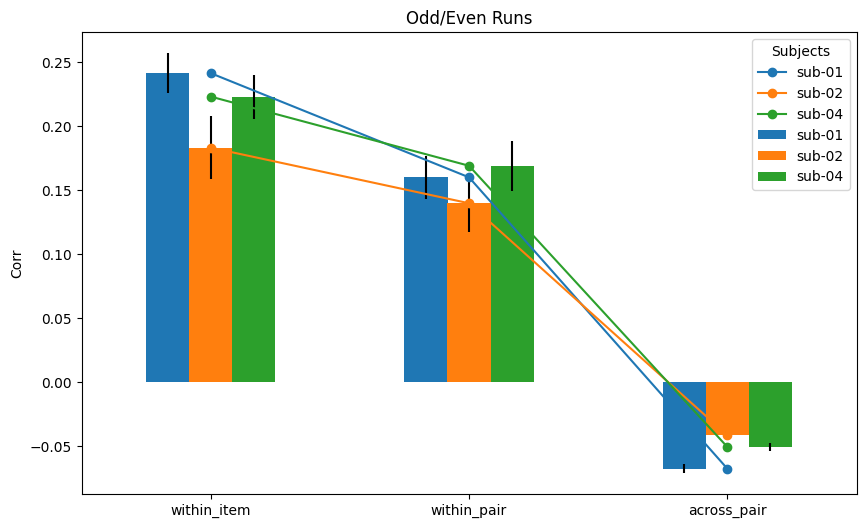

In [197]:
ax = overall_df.plot(kind='bar',  yerr=sd_df, figsize=(10, 6), rot=0) 
overall_df.plot(kind='line', marker='o',  ax=ax, legend=False)
# 3. Customize the plot using Matplotlib methods
ax.set_title('Odd/Even Runs')
#ax.set_xlabel('Types')
ax.set_ylabel('Corr')
ax.legend(title='Subjects') # Customize the legend title


# Display the plot
plt.show()

In [151]:
import matplotlib.pyplot as plt

colors = ['red', 'blue', 'green']

# 4. Plot
# We plot the first (and only) column of the transposed data
ax = overall_df[0].plot(kind='bar', color=colors, rot=0)

plt.ylabel('Values')
plt.title('Values by Column Name')
plt.show()

KeyError: 0

-0.0505666539298407

In [140]:
others[0]

array([ 0.00651036, -0.20488677,  0.06368297, -0.14780276,  0.01763922,
        0.03634962, -0.06825252, -0.02074235,  0.05986395,  0.03595794,
       -0.17482649, -0.09213582, -0.08969559, -0.10028977, -0.16189502,
       -0.09823888, -0.01431978, -0.00961822, -0.11946382,  0.00569988,
       -0.14024228,  0.08816195, -0.12656474, -0.07836284, -0.03163224,
       -0.10660735,  0.07299524, -0.09759685, -0.18410987, -0.06081165,
       -0.04672898, -0.12393396, -0.14875681,  0.0213119 ])

In [9]:
# Loading Snap data
tasks = ['study', 'test', 'snap']

test_data = {}

test_data[sub] = {}

for task in tasks:

    sub_dict = dic[sub][task]

    repeat_idx, per_run_repeat_idx = locate_repeat_index_per_run(sub_dict)
    
    test_data[sub][task] = average_repeats_across_run(sub_dict['roi'], repeat_idx, test_images) # averaging all repeats across run in the sequence of test_images

In [10]:

from torchvision import transforms
import imageio.v2 as imageio

resize_transform = transforms.Resize((224, 224))

test_img_tensor = None
img_path = f'/scratch/gpfs/KNORMAN/wanjia/mindeye_testing/real_time_mindEye2/bixby_data/afni/loaded_test_imgs.pkl'

# if os.path.exists(img_path):
#     with open(img_path, 'rb') as file:
#         test_img_tensor = pickle.load(file)
#         print('Loading image saved at: ', file)
# else:
for img in test_images:

    root_dir = os.path.join(data_folder, 'stimuli', 'scenes')
    img_list = img.split('_')[0]
    img_id = int(img.split('_')[1])

    image_file = f'{root_dir}/list{img_list}/{img_id:02d}.png'
    
    print(img_list, img_id)

    if image_file and not os.path.exists(image_file):
        print('Cannot find the image at this path',image_file)
        break

    im = imageio.imread(image_file)
    im = torch.Tensor(im / 255).permute(2,0,1)
    im = resize_transform(im.unsqueeze(0))

    if test_img_tensor is None:
        test_img_tensor = im
    else:
        test_img_tensor = torch.vstack((test_img_tensor, im))


# print(folder_path)
# with open(img_path, 'wb') as file:
#     pickle.dump(test_img_tensor, file)
#     print('image saved at: ', file)

print("testing images", test_img_tensor.shape)

A 1
A 2
A 3
A 4
A 5
A 6
A 7
A 8
A 9
A 10
A 11
A 12
A 13
A 14


/home/wg7536/.conda/envs/rt_mindEye2/lib/python3.11/site-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


A 15
A 16
A 17
A 18
B 1
B 2
B 3
B 4
B 5
B 6
B 7
B 8
B 9
B 10
B 11
B 12
B 13
B 14
B 15
B 16
B 17
B 18
testing images torch.Size([36, 3, 224, 224])


In [11]:
test_images_embeddings = torch.Tensor(test_img_tensor)
test_vox = torch.Tensor(np.mean([test_data[sub]['study'], test_data[sub]['test'], test_data[sub]['snap']], axis=0))
test_vox_study = torch.Tensor(test_data[sub]['study'])
test_vox_test = torch.Tensor(test_data[sub]['test'])
test_vox_snap = torch.Tensor(test_data[sub]['snap'])
assert len(test_images_embeddings) == len(test_vox)

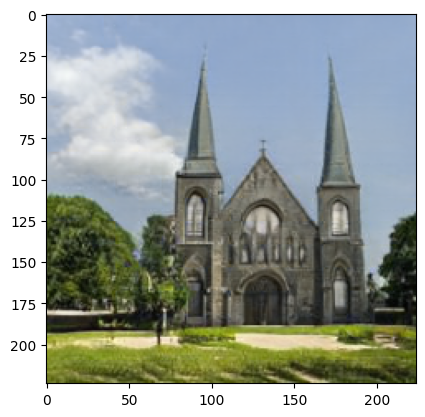

In [12]:
import matplotlib.pyplot as plt
plt.imshow(test_img_tensor[0].permute(1, 2, 0).numpy())

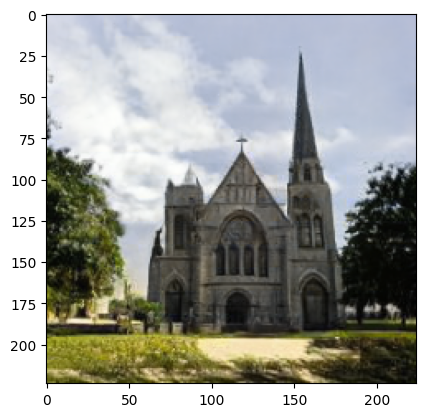

In [13]:
plt.imshow(test_img_tensor[18].permute(1, 2, 0).numpy())

### Loading pre-trained subject model

In [14]:
outdir_folder = '/scratch/gpfs/KNORMAN/wanjia/mindeye_testing/real_time_mindEye2/bixby_data/'
folder_names = {'sub-01':'sub-01_output_1771911499.2133198',
                'sub-02':'sub-02_output_1771391206.9882252', 
                'sub-04':'sub-04_output_1771391422.1811972'}

outdir = os.path.join(outdir_folder, folder_names[sub])

In [15]:
def load_ckpt(tag,load_lr=True,load_optimizer=True,load_epoch=True,strict=True,outdir=outdir,multisubj_loading=False): 
    print(f"\n---loading {outdir}/{tag}.pth ckpt---\n")
    checkpoint = torch.load(outdir+'/last.pth', map_location='cpu')
    state_dict = checkpoint['model_state_dict']
    if multisubj_loading: # remove incompatible ridge layer that will otherwise error
        state_dict.pop('ridge.linears.0.weight',None)
    model.load_state_dict(state_dict, strict=strict)
    if load_epoch:
        globals()["epoch"] = checkpoint['epoch']
        print("Epoch",epoch)
    if load_optimizer:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    if load_lr:
        lr_scheduler.load_state_dict(checkpoint['lr_scheduler'])
    del checkpoint

In [16]:
import torch.nn as nn
### Multi-GPU config ###
from accelerate import Accelerator, DeepSpeedPlugin

local_rank = os.getenv('RANK')
if local_rank is None: 
    local_rank = 0
else:
    local_rank = int(local_rank)
print("LOCAL RANK ", local_rank)  

data_type = torch.float32 # change depending on your mixed_precision

accelerator = Accelerator(split_batches=False)

device = accelerator.device

LOCAL RANK  0


In [17]:
print("PID of this process =",os.getpid())
device = accelerator.device
print("device:",device)
world_size = accelerator.state.num_processes
distributed = not accelerator.state.distributed_type == 'NO'
num_devices = torch.cuda.device_count()
if num_devices==0 or not distributed: num_devices = 1
num_workers = num_devices
print(accelerator.state)

# set data_type to match your mixed precision (automatically set based on deepspeed config)
if accelerator.mixed_precision == "bf16":
    data_type = torch.bfloat16
elif accelerator.mixed_precision == "fp16":
    data_type = torch.float16
else:
    data_type = torch.float32

print("distributed =",distributed, "num_devices =", num_devices, "local rank =", local_rank, "world size =", world_size, "data_type =", data_type)
print = accelerator.print # only print if local_rank=0

PID of this process = 2528330
device: cuda
Distributed environment: DistributedType.NO
Num processes: 1
Process index: 0
Local process index: 0
Device: cuda

Mixed precision type: no

distributed = False num_devices = 1 local rank = 0 world size = 1 data_type = torch.float32


In [18]:
from models import PriorNetwork, BrainDiffusionPrior
import utils

## USING OpenCLIP ViT-bigG ###
sys.path.append('generative_models/')
import sgm
from generative_models.sgm.modules.encoders.modules import FrozenOpenCLIPImageEmbedder
# from generative_models.sgm.models.diffusion import DiffusionEngine
# from omegaconf import OmegaConf

In [19]:
try:
    print(clip_img_embedder)
except:
    clip_img_embedder = FrozenOpenCLIPImageEmbedder(
        arch="ViT-bigG-14",
        version="laion2b_s39b_b160k",
        output_tokens=True,
        only_tokens=True,
    )
    clip_img_embedder.to(device)
clip_img_embedder.model.visual.set_grad_checkpointing(True)

clip_seq_dim = 256
clip_emb_dim = 1664

In [20]:
#num_voxels_list = [dic[sub]['study']['roi'].shape[-1]]
num_voxels_list = [5796]
n_blocks=4
hidden_dim=1024
use_prior=False
clip_scale=1.

model = utils.prepare_model_and_training(
    num_voxels_list=num_voxels_list,
    n_blocks=n_blocks,
    hidden_dim=hidden_dim,
    clip_emb_dim=clip_emb_dim,
    clip_seq_dim=clip_seq_dim,
    use_prior=use_prior,
    clip_scale=clip_scale
)

MindEyeModule()
param counts:
5,936,128 total
5,936,128 trainable
param counts:
5,936,128 total
5,936,128 trainable
param counts:
453,360,280 total
453,360,280 trainable
param counts:
459,296,408 total
459,296,408 trainable


In [21]:
epoch = 0
losses, test_losses, lrs = [], [], []
best_test_loss = 1e9
torch.cuda.empty_cache()
# tf32 data type is faster than standard float32
torch.backends.cuda.matmul.allow_tf32 = True


In [22]:
load_ckpt("last",
          outdir=outdir,load_lr=False,load_optimizer=False,load_epoch=False,strict=False,multisubj_loading=True)
model.to(device)


---loading /scratch/gpfs/KNORMAN/wanjia/mindeye_testing/real_time_mindEye2/bixby_data/sub-01_output_1771911499.2133198/last.pth ckpt---



MindEyeModule(
  (ridge): RidgeRegression(
    (linears): ModuleList(
      (0): Linear(in_features=5796, out_features=1024, bias=True)
    )
  )
  (backbone): BrainNetwork(
    (mixer_blocks1): ModuleList(
      (0-3): 4 x Sequential(
        (0): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (1): Sequential(
          (0): Linear(in_features=1024, out_features=1024, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.15, inplace=False)
          (3): Linear(in_features=1024, out_features=1024, bias=True)
        )
      )
    )
    (mixer_blocks2): ModuleList(
      (0-3): 4 x Sequential(
        (0): LayerNorm((1,), eps=1e-05, elementwise_affine=True)
        (1): Sequential(
          (0): Linear(in_features=1, out_features=1, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.15, inplace=False)
          (3): Linear(in_features=1, out_features=1, bias=True)
        )
      )
    )
    (backbone_linear): Linear(i

In [58]:
test_data = torch.utils.data.TensorDataset(torch.tensor(range(len(test_images))))
test_dl = torch.utils.data.DataLoader(test_data, batch_size=36, shuffle=False, drop_last=True, pin_memory=True)

In [60]:
for test_i, behav in enumerate(test_dl):  
    print(test_i)
    print(behav[0])
    break

0
tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35])


In [61]:
behav[0].ndim

1

In [ ]:
with torch.no_grad(), torch.cuda.amp.autocast(dtype=data_type): 
    for test_i, behav in enumerate(test_dl):  
        
        behav = behav[0]

        loss=0.

        if behav.ndim>1:
            image = images[behav[:,0].long().cpu()].to(device)
            voxel = vox[behav.long().cpu()].mean(1)
        else:
            image = images[behav.long().cpu()].to(device)
            voxel = vox[behav.long().cpu()]

        voxel = torch.Tensor(voxel).unsqueeze(1).to(device)

        clip_img_embedder = clip_img_embedder.to(device)
        clip_target = clip_img_embedder(image.float())

        voxel_ridge = model.ridge(voxel,0)

        backbone, clip_voxels, blurry_image_enc_ = model.backbone(voxel_ridge)

        if clip_scale>0:
            clip_voxels_norm = nn.functional.normalize(clip_voxels.flatten(1), dim=-1)
            clip_target_norm = nn.functional.normalize(clip_target.flatten(1), dim=-1)

        # for some evals, only doing a subset of the samples per batch because of computational cost
        random_samps = np.random.choice(np.arange(len(image)), size=len(image)//5, replace=False)

        if use_prior:
            loss_prior, contaminated_prior_out = model.diffusion_prior(text_embed=backbone[random_samps], image_embed=clip_target[random_samps])
            test_loss_prior_total += loss_prior.item()
            loss_prior *= prior_scale
            loss += loss_prior

        if clip_scale>0:
            loss_clip = utils.soft_clip_loss(
                clip_voxels_norm,
                clip_target_norm,
                temp=.006)

            test_loss_clip_total += loss_clip.item()
            loss_clip = loss_clip * clip_scale
            loss += loss_clip

        if clip_scale>0:
            # forward and backward top 1 accuracy        
            labels = torch.arange(len(clip_voxels_norm)).to(clip_voxels_norm.device) 
            test_fwd_percent_correct += utils.topk(utils.batchwise_cosine_similarity(clip_voxels_norm, clip_target_norm), labels, k=1).item()
            test_bwd_percent_correct += utils.topk(utils.batchwise_cosine_similarity(clip_target_norm, clip_voxels_norm), labels, k=1).item()

        utils.check_loss(loss)                
        test_losses.append(loss.item())

In [23]:
for img in test_images:
    
    pairs = []
    
    for i in range(1,19):
        
        a = f'A_{i}'
        b = f'B_{i}'

        pairs.append([test_images.index(a), test_images.index(b)])


In [24]:
for i, pair in enumerate(pairs):
    print(pair)

[0, 18]
[1, 19]
[2, 20]
[3, 21]
[4, 22]
[5, 23]
[6, 24]
[7, 25]
[8, 26]
[9, 27]
[10, 28]
[11, 29]
[12, 30]
[13, 31]
[14, 32]
[15, 33]
[16, 34]
[17, 35]


In [26]:
score = 0
total = 0

vox = test_vox_snap
images = test_images_embeddings

with torch.no_grad(), torch.cuda.amp.autocast(dtype=data_type):
    for pair in pairs:
        voxel = vox[pair[0]].to(device)[None]
        voxel = torch.Tensor(voxel).unsqueeze(1).to(device)

        imageA = images[pair[0]].to(device)[None]
        imageB = images[pair[1]].to(device)[None]

        clip_targetA = clip_img_embedder(imageA.float())
        clip_targetB = clip_img_embedder(imageB.float())

        voxel_ridge = model.ridge(voxel,0)
        backbone, clip_voxels, _ = model.backbone(voxel_ridge)

        clip_voxels_norm = nn.functional.normalize(clip_voxels.flatten(1), dim=-1)
        clip_targetA_norm = nn.functional.normalize(clip_targetA.flatten(1), dim=-1)
        clip_targetB_norm = nn.functional.normalize(clip_targetB.flatten(1), dim=-1)

        voxel1 = clip_voxels_norm

        if utils.batchwise_cosine_similarity(clip_voxels_norm, clip_targetA_norm) > utils.batchwise_cosine_similarity(clip_voxels_norm, clip_targetB_norm):
            score += 1
        total += 1

        voxel = vox[pair[1]].to(device)[None]
        voxel = torch.Tensor(voxel).unsqueeze(1).to(device)

        voxel_ridge = model.ridge(voxel,0)
        backbone, clip_voxels, _ = model.backbone(voxel_ridge)
        clip_voxels_norm = nn.functional.normalize(clip_voxels.flatten(1), dim=-1)

        if utils.batchwise_cosine_similarity(clip_voxels_norm, clip_targetB_norm) > utils.batchwise_cosine_similarity(clip_voxels_norm, clip_targetA_norm):
            score += 1
        total += 1

        print('voxels similarity:', utils.pairwise_cosine_similarity(voxel1, clip_voxels_norm))
        print('image/voxel similarity:', utils.pairwise_cosine_similarity(voxel1, clip_targetA_norm))
        print('comp_image/voxel similarity:',utils.pairwise_cosine_similarity(voxel1, clip_targetB_norm))
        
        break
        
    print('score:', score)
    print('total:', total)
    

print(score/total)

voxels similarity: tensor([[0.9788]], device='cuda:0')
image/voxel similarity: tensor([[0.1885]], device='cuda:0')
comp_image/voxel similarity: tensor([[0.1936]], device='cuda:0')
score: 1
total: 2
0.5


/home/wg7536/.conda/envs/rt_mindEye2/lib/python3.11/site-packages/torch/utils/checkpoint.py:429: UserWarning: torch.utils.checkpoint: please pass in use_reentrant=True or use_reentrant=False explicitly. The default value of use_reentrant will be updated to be False in the future. To maintain current behavior, pass use_reentrant=True. It is recommended that you use use_reentrant=False. Refer to docs for more details on the differences between the two variants.
  warnings.warn(
/home/wg7536/.conda/envs/rt_mindEye2/lib/python3.11/site-packages/torch/utils/checkpoint.py:61: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


In [27]:
nn.functional.normalize(clip_voxels.flatten(1), dim=-1)

tensor([[-0.0010,  0.0009,  0.0011,  ...,  0.0021, -0.0003,  0.0020]],
       device='cuda:0')

In [36]:
clip_voxels.shape

torch.Size([1, 256, 1664])

In [35]:
clip_targetA.shape

torch.Size([1, 256, 1664])

In [37]:
voxel

tensor([[[ 0.3289,  0.4320, -0.1955,  ..., -0.1566, -0.2682,  0.0033]]],
       device='cuda:0')

In [38]:
vox

tensor([[-0.4217, -0.4834, -0.2882,  ..., -0.1139, -0.2130,  0.2208],
        [-0.3296, -0.4946, -0.0079,  ..., -0.1741, -0.1967, -0.3156],
        [-0.1096,  0.1062, -0.6312,  ..., -0.1087, -0.4311, -0.1694],
        ...,
        [ 0.4433,  0.5936,  0.5124,  ..., -0.5453, -0.6079, -0.4445],
        [ 0.0988, -0.2032,  0.0261,  ...,  0.0103, -0.0503, -0.0426],
        [-0.2158,  0.0338, -0.0069,  ...,  0.1763,  0.2628,  0.2358]])

In [45]:
 pair

[0, 18]

In [53]:
torch.Tensor(vox[pair[1]])

tensor([ 0.3289,  0.4320, -0.1955,  ..., -0.1566, -0.2682,  0.0033])

In [56]:
utils.batchwise_cosine_similarity(torch.Tensor(vox[pair[0]][None]), torch.Tensor(vox[pair[1]][None]))

tensor([[0.1184]])

In [57]:
utils.batchwise_cosine_similarity(voxel1, clip_voxels_norm)

tensor([[0.9788]], device='cuda:0')

In [119]:
def evaluate_mst_pairs(vox_idx, vox, img_idx, images):

    score = 0
    total = 0
    
    with torch.no_grad(), torch.cuda.amp.autocast(dtype=data_type):
        for i, pair in enumerate(vox_idx):
            voxel = vox[pair[0]].to(device)[None]
            voxel = torch.Tensor(voxel).unsqueeze(1).to(device)
            
            imageA = images[img_idx[i][0]].to(device)[None]
            imageB = images[img_idx[i][1]].to(device)[None]
            
            clip_targetA = clip_img_embedder(imageA.float())
            clip_targetB = clip_img_embedder(imageB.float())
            
            voxel_ridge = model.ridge(voxel,0)
            backbone, clip_voxels, _ = model.backbone(voxel_ridge)
            
            clip_voxels_norm = nn.functional.normalize(clip_voxels.flatten(1), dim=-1)
            clip_targetA_norm = nn.functional.normalize(clip_targetA.flatten(1), dim=-1)
            clip_targetB_norm = nn.functional.normalize(clip_targetB.flatten(1), dim=-1)
            
            voxel1 = clip_voxels_norm
            
            
            if utils.batchwise_cosine_similarity(clip_voxels_norm, clip_targetA_norm) > utils.batchwise_cosine_similarity(clip_voxels_norm, clip_targetB_norm):
                score += 1
            total += 1
            
            voxel = vox[pair[1]].to(device)[None]
            voxel = torch.Tensor(voxel).unsqueeze(1).to(device)
            
            voxel_ridge = model.ridge(voxel,0)
            backbone, clip_voxels, _ = model.backbone(voxel_ridge)
            clip_voxels_norm = nn.functional.normalize(clip_voxels.flatten(1), dim=-1)
            
            if utils.batchwise_cosine_similarity(clip_voxels_norm, clip_targetB_norm) > utils.batchwise_cosine_similarity(clip_voxels_norm, clip_targetA_norm):
                score += 1
            total += 1
            
            print('voxels similarity:', utils.batchwise_cosine_similarity(voxel1, clip_voxels_norm))
            print('image/voxel similarity:', utils.batchwise_cosine_similarity(voxel1, clip_targetA_norm))
            print('comp_image/voxel similarity:',utils.batchwise_cosine_similarity(voxel1, clip_targetB_norm))

        print('score:', score)
        print('total:', total)
            
    return score/total

In [72]:
vox = test_vox
images = test_images_embeddings

def evaluate_mst_pairs(mst_pairs):
    score = 0
    total = 0
    
    with torch.no_grad(), torch.cuda.amp.autocast(dtype=data_type):
        for pair in mst_pairs:
            voxel = vox[pair[0]].to(device)[None]
            voxel = torch.Tensor(voxel).unsqueeze(1).to(device)
            
            imageA = images[image_idx[pair[0]]].to(device)[None]
            imageB = images[image_idx[pair[1]]].to(device)[None]
            
            clip_targetA = clip_img_embedder(imageA.float())
            clip_targetB = clip_img_embedder(imageB.float())
            
            voxel_ridge = model.ridge(voxel,0)
            backbone, clip_voxels, _ = model.backbone(voxel_ridge)
            
            clip_voxels_norm = nn.functional.normalize(clip_voxels.flatten(1), dim=-1)
            clip_targetA_norm = nn.functional.normalize(clip_targetA.flatten(1), dim=-1)
            clip_targetB_norm = nn.functional.normalize(clip_targetB.flatten(1), dim=-1)
            
            if utils.batchwise_cosine_similarity(clip_voxels_norm, clip_targetA_norm) > utils.batchwise_cosine_similarity(clip_voxels_norm, clip_targetB_norm):
                score += 1
            total += 1
            
            voxel = vox[image_idx[pair[1]]].to(device)[None]
            voxel = torch.Tensor(voxel).unsqueeze(1).to(device)
            
            voxel_ridge = model.ridge(voxel,0)
            backbone, clip_voxels, _ = model.backbone(voxel_ridge)
            clip_voxels_norm = nn.functional.normalize(clip_voxels.flatten(1), dim=-1)
            
            if utils.batchwise_cosine_similarity(clip_voxels_norm, clip_targetB_norm) > utils.batchwise_cosine_similarity(clip_voxels_norm, clip_targetA_norm):
                score += 1
            total += 1
            
    return score/total

print(evaluate_mst_pairs(pairs))

/home/wg7536/.conda/envs/rt_mindEye2/lib/python3.11/site-packages/torch/utils/checkpoint.py:429: UserWarning: torch.utils.checkpoint: please pass in use_reentrant=True or use_reentrant=False explicitly. The default value of use_reentrant will be updated to be False in the future. To maintain current behavior, pass use_reentrant=True. It is recommended that you use use_reentrant=False. Refer to docs for more details on the differences between the two variants.
  warnings.warn(
/home/wg7536/.conda/envs/rt_mindEye2/lib/python3.11/site-packages/torch/utils/checkpoint.py:61: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


0.5


In [21]:
test_images_embeddings.shape

torch.Size([36, 3, 224, 224])

In [22]:
test_vox.shape

torch.Size([36, 3643])

In [23]:
test_dl = torch.utils.data.DataLoader(test_vox, batch_size=36, shuffle=False, drop_last=True, pin_memory=True)
images = test_images_embeddings

In [24]:
len(test_vox)

36

In [25]:
test_data = torch.utils.data.TensorDataset(torch.tensor(range(len(test_vox))))
test_dl = torch.utils.data.DataLoader(test_data, batch_size=36, shuffle=False, drop_last=True, pin_memory=True)

for test_i, behav in enumerate(test_dl):  
    behav = behav[0]
    print(behav.ndim>1)

False


In [26]:
images = torch.Tensor(test_images_embeddings)
vox = torch.Tensor(test_vox)

In [27]:
image = images[behav.long().cpu()].to(device)
voxel = vox[behav.long().cpu()]

In [28]:
voxel.shape

torch.Size([36, 3643])

In [29]:
image.dtype

torch.float32

In [30]:
voxel = torch.Tensor(voxel).unsqueeze(1).to(device)

In [31]:
voxel.shape

torch.Size([36, 1, 3643])

In [32]:
clip_img_embedder = clip_img_embedder.to(device)
clip_target = clip_img_embedder(image)

In [33]:
clip_target.dtype

torch.float16

In [34]:
voxel_ridge = model.ridge(voxel,0)

In [35]:
voxel_ridge.shape

torch.Size([36, 1, 1024])

In [36]:
backbone, clip_voxels, blurry_image_enc_ = model.backbone(voxel_ridge)

In [37]:
clip_voxels_norm = nn.functional.normalize(clip_voxels.flatten(1), dim=-1)
clip_target_norm = nn.functional.normalize(clip_target.flatten(1), dim=-1)

In [38]:
clip_voxels_norm.dtype

torch.float32

In [43]:
clip_target_norm.float().dtype

torch.float32

In [83]:
type(clip_voxels_norm)

torch.Tensor

In [82]:
type(clip_target_norm)

torch.Tensor

In [78]:
random_samps = np.random.choice(np.arange(len(image)), size=len(image)//5, replace=False)

In [59]:
test_fwd_percent_correct = 0.
test_bwd_percent_correct = 0.

In [60]:
# forward and backward top 1 accuracy        
labels = torch.arange(len(clip_voxels_norm)).to(clip_voxels_norm.device) 
test_fwd_percent_correct += utils.topk(utils.batchwise_cosine_similarity(clip_voxels_norm, clip_target_norm.float()), labels, k=1).item()
test_bwd_percent_correct += utils.topk(utils.batchwise_cosine_similarity(clip_target_norm.float(), clip_voxels_norm), labels, k=1).item()

In [61]:
test_fwd_percent_correct

0.1388888955116272

In [62]:
test_bwd_percent_correct

0.0833333358168602

In [31]:
if local_rank==0:
    test_fwd_percent_correct = 0.
    test_bwd_percent_correct = 0.
    with torch.no_grad(), torch.cuda.amp.autocast(dtype=data_type): 
        for test_i, behav in enumerate(test_dl):  
            behav = behav[0]

            loss=0.

            if behav.ndim>1:
                image = images[behav[:,0].long().cpu()].to(device)
                voxel = vox[behav.long().cpu()].mean(1)
            else:
                image = images[behav.long().cpu()].to(device)
                voxel = vox[behav.long().cpu()]

            voxel = torch.Tensor(voxel).unsqueeze(1).to(device)

            clip_img_embedder = clip_img_embedder.to(device)
            clip_target = clip_img_embedder(image.float())

            voxel_ridge = model.ridge(voxel,0)

            backbone, clip_voxels, blurry_image_enc_ = model.backbone(voxel_ridge)

            if clip_scale>0:
                clip_voxels_norm = nn.functional.normalize(clip_voxels.flatten(1), dim=-1)
                clip_target_norm = nn.functional.normalize(clip_target.flatten(1), dim=-1)

            # for some evals, only doing a subset of the samples per batch because of computational cost
            random_samps = np.random.choice(np.arange(len(image)), size=len(image)//5, replace=False)

            if clip_scale>0:
                loss_clip = utils.soft_clip_loss(
                    clip_voxels_norm,
                    clip_target_norm,
                    temp=.006)

                test_loss_clip_total += loss_clip.item()
                loss_clip = loss_clip * clip_scale
                loss += loss_clip

            if clip_scale>0:
                # forward and backward top 1 accuracy        
                labels = torch.arange(len(clip_voxels_norm)).to(clip_voxels_norm.device) 
                test_fwd_percent_correct += utils.topk(utils.batchwise_cosine_similarity(clip_voxels_norm, clip_target_norm), labels, k=1).item()
                test_bwd_percent_correct += utils.topk(utils.batchwise_cosine_similarity(clip_target_norm, clip_voxels_norm), labels, k=1).item()

            utils.check_loss(loss)                
            test_losses.append(loss.item())
            
            print("test/test_fwd_pct_correct: ", test_fwd_percent_correct / (test_i + 1))
            print("test/test_bwd_pct_correct: ",test_bwd_percent_correct / (test_i + 1))

NameError: name 'test_i' is not defined